In [1]:
import sionna.rt as rt
import mitsuba as mi
import numpy as np
import drjit as dr
import matplotlib.pyplot as plt


In [2]:
def default_array(num_rows: int = 1, num_cols: int = 1,
                  vertical_spacing: float = 0.5, horizontal_spacing: float = 0.5,
                  pattern: str = "iso", polarization: str = "V"):
    return rt.PlanarArray(num_rows=num_rows,
                       num_cols=num_cols,
                       vertical_spacing=vertical_spacing,
                       horizontal_spacing=horizontal_spacing,
                       pattern=pattern,
                       polarization=polarization)

In [3]:
N = 100
vert_x, vert_y = np.meshgrid(
    np.linspace(0, 10, N),
    np.linspace(0, 10, N),
    indexing="xy")
elevation = (np.sin(2 * vert_x) + np.sin(2 * vert_y)) / 2 / 10
mesh = rt.utils.geometry.triangulate_elevation(mi.TensorXf(elevation))
vertices = dr.reshape(mi.Point3f, mesh.vertex_positions_buffer(), (3, -1))


# Create scene
props = mi.Properties()
props["material"] = rt.RadioMaterial(
    name="lunar-highland",
    thickness=11,
    relative_permittivity=2.7,
    conductivity=10**(-12.5),
    scattering_coefficient=0.4,
    xpd_coefficient=0.1,
    scattering_pattern='lambertian',
    frequency_update_callback=None,
    color=None,
    props=None)
# props["material"] = rt.ITURadioMaterial("mat", itu_type="concrete", thickness=10)
# props["material"] = rt.ITURadioMaterial("mat", itu_type="glass", thickness=1)
# props["material"] = rt.RadioMaterial("mat", thickness=10, relative_permittivity=100)
# Sionna requires bsdfs to be wrapped in HolderMaterial
props["material"] = rt.HolderMaterial(props)
mi_mesh = mi.Mesh(name="terrain",
                  vertex_count=mesh.vertex_count(),
                  face_count=mesh.face_count(), 
                  props=props)
mesh_params = mi.traverse(mesh)
mi_mesh_params = mi.traverse(mi_mesh)
mi_mesh_params["vertex_positions"] = mesh_params["vertex_positions"]
mi_mesh_params["faces"] = mesh_params["faces"]
mi_mesh_params.update()
scene = rt.Scene(mi.load_dict({
    "type": "scene",
    "terrain": mi_mesh
}))

scene.tx_array = default_array()
scene.rx_array = default_array(polarization="VH")
tx = rt.Transmitter(name="tx",
                 position=mi.Point3f(0, 0, 0.1),
                 orientation=mi.Point3f(0,0,0),
                 power_dbm=100)
tx.display_radius = 0.01
scene.add(tx)

In [4]:
rm_solver = rt.RadioMapSolver()
rm = rm_solver(
    scene=scene,
    cell_size=[0.05, 0.05],
    # evaluate 1cm above the surface
    digital_elevation_model=mi.TensorXf(elevation) + 0.001,
    samples_per_tx=int(1e8),
    max_depth=3,
    los=True,
    specular_reflection=True,
    diffuse_reflection=True,
    refraction=True
)

Text(0.5, 1.0, 'norm')

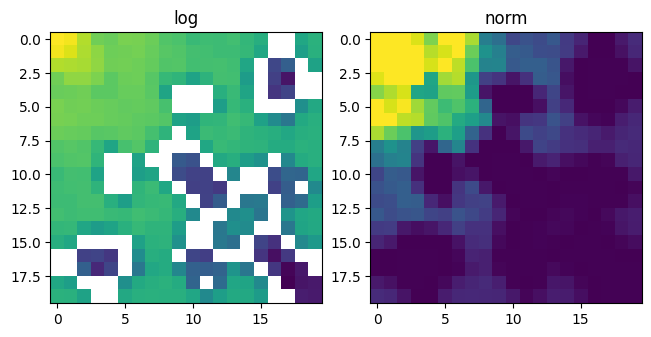

In [5]:
from matplotlib.colors import Normalize, LogNorm

fig, axs = plt.subplots(ncols=2, layout="constrained")
pg = rm.path_gain.numpy().squeeze()
qmin, qmax = np.quantile(pg, [0.05, 0.95])
axs[0].imshow(rm.path_gain.numpy().squeeze(), norm="log")
axs[1].imshow(rm.path_gain.numpy().squeeze(), norm=Normalize(qmin, qmax))
axs[0].set_title("log")
axs[1].set_title("norm")
# axs[1].imshow(elevation.numpy(), cmap="grey")

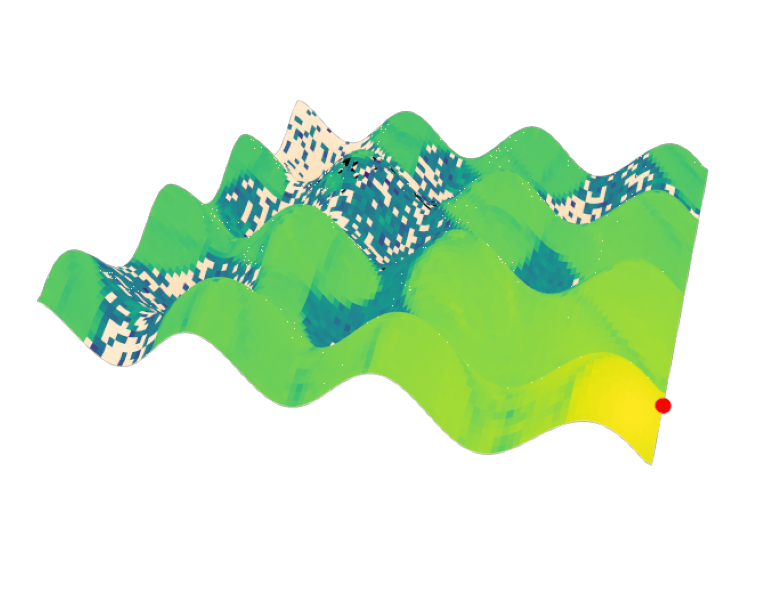

In [7]:
# cam = rt.Camera(position=[-15, 10, 5], look_at=[5, 5, 2])
cam = rt.Camera(position=[-1, 0, 0.8], look_at=[0.3, 0.5, 0])
rm.resample([0.01, 0.01])
scene.render(camera=cam, show_devices=True, radio_map=rm);
# scene.preview(show_devices=True, radio_map=rm);
# scene.preview(show_devices=True);

In [8]:
scene.preview(show_devices=True, radio_map=rm);

In [ ]:
assert False

AssertionError: 

In [ ]:
# meas_surface =  mi.Mesh(name="meas_surface",
#                         vertex_count=mesh.vertex_count(),
#                         face_count=mesh.face_count(), 
#                         props=props)
# ms_params = mi.traverse(meas_surface)
# vertices = dr.reshape(mi.Point3f, mesh_params["vertex_positions"], (3, -1))
# vertices.z += 1e-4
# ms_params["vertex_positions"] = dr.ravel(vertices)
# ms_params["faces"] = mesh_params["faces"]
# ms_params.update()
meas_surface = rt.utils.geometry.triangulate_elevation(mi.TensorXf(elevation + 1e-3))

In [ ]:
rm_solver = rt.RadioMapSolver()
rm_solver.loop_mode = "evaluated"
rm_mesh: rt.MeshRadioMap = rm_solver(
    scene=scene,
    cell_size=[10, 10],
    measurement_surface=meas_surface, 
    samples_per_tx=int(1e7),
    max_depth=5,
    los=True,
    specular_reflection=True,
    diffuse_reflection=True,
    refraction=True
)

In [ ]:
# plt.plot(rm_mesh.path_gain.numpy().squeeze())

In [ ]:
p = np.nanmean(rm_mesh.path_gain.numpy().reshape(2, 100, 100), axis=0)
plt.imshow(p, norm="log")

In [ ]:
path_gain = rm_mesh.path_gain.numpy().reshape(2, N, N)
path_gain = np.tile(np.nanmean(path_gain, axis=0).ravel(), 2)
rm_mesh._pathgain_map = dr.reshape(mi.TensorXf, mi.Float(path_gain), (1, -1))

In [ ]:
scene.preview(show_devices=True, radio_map=rm_mesh);